# Day 4 — Four-Metric Explanation Evaluation
### MSc Dissertation — Rajarajachozhan V K (03189049)
**Comparative Evaluation of Explainable AI Methods for Customer Churn Prediction**
*A SHAP- and LIME-Based Framework with Marketer-Oriented Segmentation*

---
**Purpose:** Formally evaluate SHAP vs LIME on the best model (XGBoost) across the
four metrics defined in the proposal — **fidelity, stability, sparsity, agreement** —
computed per-instance over the canonical 500-customer eval set.

**Inputs:** `xgb_shap_eval.csv`, `lime_eval.csv`, `*_tuned.pkl`, `test_data.pkl`, `shap_outputs.pkl`

**Outputs:** `evaluation_metrics.pkl`, `metric_summary.csv` + comparison figures

**Method notes:**
- Fidelity: deletion-AOPC (masking-based faithfulness, Samek et al. 2017) — a tractable
  alternative to full remove-and-retrain (ROAR); complemented by LIME local R² from Day 3.
- Stability: input-perturbation (same protocol for both methods) + LIME seed-variance.
- Sparsity: features exceeding 5% of the per-instance max attribution.
- Agreement: feature / rank / sign agreement (Krishna et al. 2022) computed per instance.

**Phase:** 7 (four-metric evaluation) → feeds Phase 8 (SHAP-based segmentation).

---

In [3]:
# ============================================================
# SETUP
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = "/content/drive/MyDrive/MSc_Dissertation/data/"
MODEL_PATH = "/content/drive/MyDrive/MSc_Dissertation/models/"

!pip install xgboost imbalanced-learn shap lime -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# ============================================================
# IMPORTS + CONFIG + HELPERS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap, pickle, time, warnings
import lime, lime.lime_tabular
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')
np.random.seed(42)

# ---- Config ----
TOPK_LIST   = [5, 10]     # k values for agreement
FID_K       = 15          # deletion steps for fidelity AOPC
STAB_N      = 40          # instances for stability (subset, keeps it fast)
STAB_M      = 5           # perturbed copies per instance
STAB_SIGMA  = 0.02        # noise std on scaled continuous features
LIME_SEEDS  = [1, 2, 3]   # for LIME seed-variance instability
SPARSE_THR  = 0.05        # 5% of per-instance max attribution
NUM_SAMPLES = 2000        # LIME perturbations (stability recompute)

def churn_class(raw):
    if isinstance(raw, list): return np.asarray(raw[1])
    raw = np.asarray(raw)
    return raw[:, :, 1] if raw.ndim == 3 else raw

def lime_to_vector(exp, n, label=1):
    v = np.zeros(n)
    for fi, w in exp.as_map()[label]: v[fi] = w
    return v

def mean_pairwise_cosine(vs):
    vs = np.asarray(vs, float)
    nrm = np.linalg.norm(vs, axis=1, keepdims=True); nrm[nrm == 0] = 1e-12
    u = vs / nrm; S = u @ u.T
    iu = np.triu_indices(len(vs), 1)
    return float(S[iu].mean())

In [5]:
# ============================================================
# STEP 1: LOAD ARTIFACTS + REBUILD EXPLAINERS (locked Day 3 config)
# ============================================================
print("="*60); print("STEP 1: LOADING ARTIFACTS"); print("="*60)

xgb_model = pickle.load(open(MODEL_PATH + 'xgboost_tuned.pkl', 'rb'))
test_data = pickle.load(open(MODEL_PATH + 'test_data.pkl', 'rb'))
X_test_scaled     = test_data['X_test_scaled']
y_test            = test_data['y_test']
feature_names     = test_data['feature_names']
n_feat = len(feature_names)

shap_eval = pd.read_csv(MODEL_PATH + 'xgb_shap_eval.csv', index_col=0).reindex(columns=feature_names)
lime_eval = pd.read_csv(MODEL_PATH + 'lime_eval.csv',     index_col=0).reindex(columns=feature_names)
lime_eval.index = lime_eval.index.astype(shap_eval.index.dtype)
eval_idx = shap_eval.index
assert (shap_eval.index == lime_eval.index).all(), "Index mismatch between SHAP and LIME!"
print(f"SHAP eval: {shap_eval.shape} | LIME eval: {lime_eval.shape} | aligned OK")

# Rebuild explainers (locked config: default kernel width, binaries categorical)
cat_idx = [i for i, f in enumerate(feature_names) if X_test_scaled[f].nunique() <= 2]
cont_idx = [i for i in range(n_feat) if i not in cat_idx]
xgb_tree = shap.TreeExplainer(xgb_model)
predict_fn = lambda x: xgb_model.predict_proba(pd.DataFrame(x, columns=feature_names))
def build_lime(seed=42):
    return lime.lime_tabular.LimeTabularExplainer(
        training_data=X_test_scaled.values, feature_names=feature_names,
        class_names=['Non-Churn','Churn'], categorical_features=cat_idx,
        mode='classification', discretize_continuous=False, random_state=seed)
lime_explainer = build_lime(42)
print(f"Explainers ready. Continuous features: {len(cont_idx)}, binary: {len(cat_idx)}")

STEP 1: LOADING ARTIFACTS
SHAP eval: (500, 66) | LIME eval: (500, 66) | aligned OK
Explainers ready. Continuous features: 34, binary: 32


In [6]:
# ============================================================
# STEP 2: AGREEMENT METRIC  (Krishna et al. 2022)
#   feature agreement@k, rank agreement@k, sign agreement@k
# ============================================================
print("\n"+"="*60); print("STEP 2: AGREEMENT (SHAP vs LIME)"); print("="*60)

def agreement(sv, lv, k):
    s = np.argsort(-np.abs(sv))[:k]; l = np.argsort(-np.abs(lv))[:k]
    inter = set(s) & set(l)
    fa = len(inter) / k
    ra = np.mean([s[j] == l[j] for j in range(k)])          # same feature, same position
    sign = (np.mean([np.sign(sv[i]) == np.sign(lv[i]) for i in inter])
            if inter else np.nan)                           # directional consistency
    return fa, ra, sign

agr = {k: {'FA': [], 'RA': [], 'SA': []} for k in TOPK_LIST}
signed_rho = []
for idx in eval_idx:
    sv, lv = shap_eval.loc[idx].values, lime_eval.loc[idx].values
    signed_rho.append(spearmanr(sv, lv)[0])
    for k in TOPK_LIST:
        fa, ra, sa = agreement(sv, lv, k)
        agr[k]['FA'].append(fa); agr[k]['RA'].append(ra); agr[k]['SA'].append(sa)

print(f"{'metric':<22}{'mean':>8}")
agreement_summary = {}
for k in TOPK_LIST:
    for m, name in [('FA','Feature agreement'), ('RA','Rank agreement'), ('SA','Sign agreement')]:
        val = np.nanmean(agr[k][m])
        agreement_summary[f'{name}@{k}'] = val
        print(f"{name+'@'+str(k):<22}{val:>8.3f}")
agreement_summary['Signed rank corr (mean)'] = np.nanmean(signed_rho)
print(f"{'Signed Spearman (mean)':<22}{np.nanmean(signed_rho):>8.3f}")


STEP 2: AGREEMENT (SHAP vs LIME)
metric                    mean
Feature agreement@5      0.137
Rank agreement@5         0.021
Sign agreement@5         0.131
Feature agreement@10     0.149
Rank agreement@10        0.014
Sign agreement@10        0.188
Signed Spearman (mean)  -0.061



STEP 3: SPARSITY
  SHAP mean active features   28.63
  LIME mean active features   48.23
  SHAP median                 29.00
  LIME median                 51.00


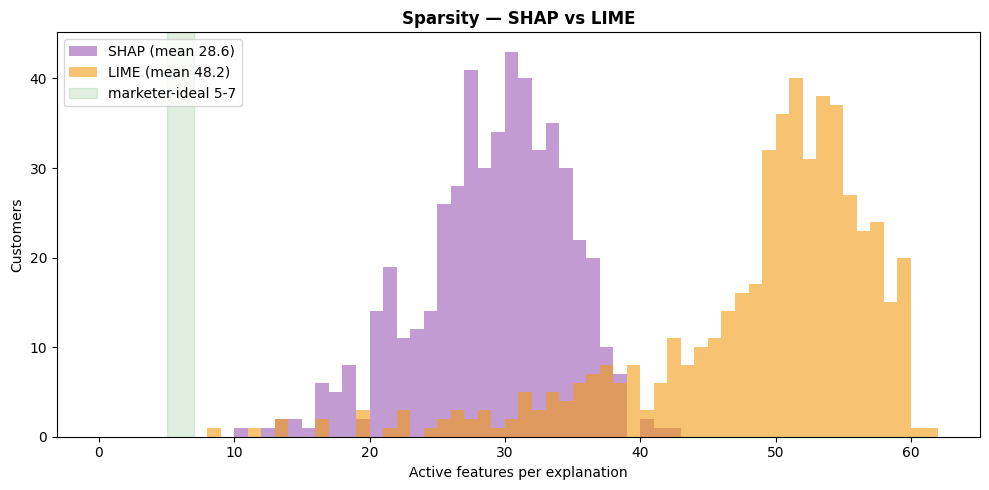

In [7]:
# ============================================================
# STEP 3: SPARSITY METRIC
#   # features with |attr| > 5% of the per-instance max |attr|
#   (proposal target for marketer-actionable explanations: ~5-7)
# ============================================================
print("\n"+"="*60); print("STEP 3: SPARSITY"); print("="*60)

def sparsity(df):
    A = np.abs(df.values)
    thr = SPARSE_THR * A.max(axis=1, keepdims=True)
    return (A > thr).sum(axis=1)   # active-feature count per instance

shap_sp, lime_sp = sparsity(shap_eval), sparsity(lime_eval)
sparsity_summary = {
    'SHAP mean active features': shap_sp.mean(),
    'LIME mean active features': lime_sp.mean(),
    'SHAP median': np.median(shap_sp),
    'LIME median': np.median(lime_sp),
}
for k, v in sparsity_summary.items(): print(f"  {k:<28}{v:.2f}")

plt.figure(figsize=(10, 5))
bins = np.arange(0, max(shap_sp.max(), lime_sp.max())+2)
plt.hist(shap_sp, bins=bins, alpha=.6, label=f'SHAP (mean {shap_sp.mean():.1f})', color='#9b59b6')
plt.hist(lime_sp, bins=bins, alpha=.6, label=f'LIME (mean {lime_sp.mean():.1f})', color='#f39c12')
plt.axvspan(5, 7, color='green', alpha=.12, label='marketer-ideal 5-7')
plt.xlabel('Active features per explanation'); plt.ylabel('Customers')
plt.title('Sparsity — SHAP vs LIME', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()


STEP 4: FIDELITY (deletion AOPC)
  SHAP deletion-AOPC      0.5814
  LIME deletion-AOPC      0.5377
  Random deletion-AOPC    0.3831
  (higher = the explainer's top features move the prediction more)


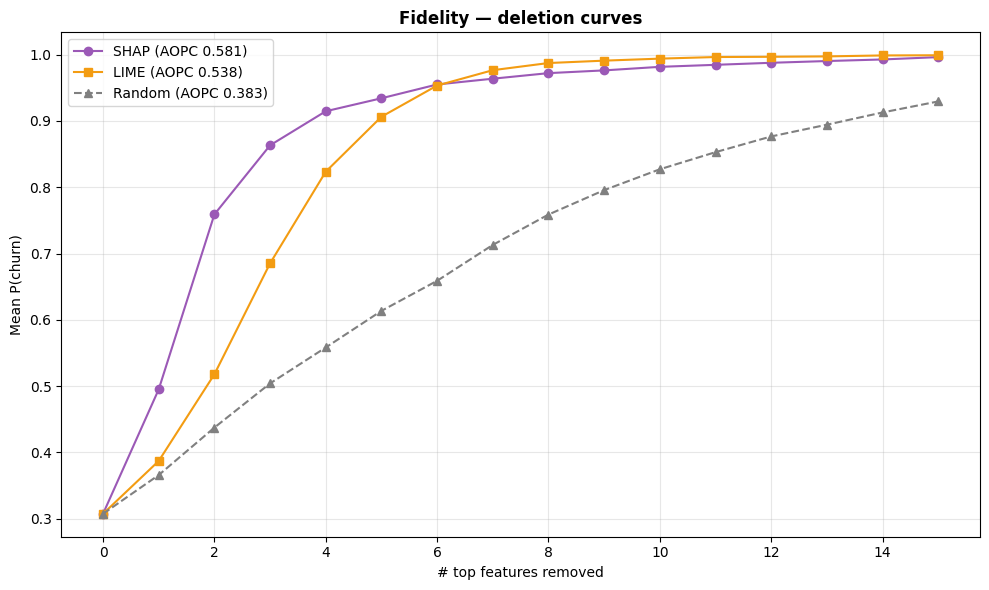

In [8]:
# ============================================================
# STEP 4: FIDELITY METRIC — deletion AOPC (no retraining)
#   Mask top-k features (by |attr|) with baseline, measure how much
#   P(churn) MOVES. Bigger move = ranking more faithful. (abs change,
#   so extreme-prediction customers don't cancel out to negatives.)
# ============================================================
print("\n"+"="*60); print("STEP 4: FIDELITY (deletion AOPC)"); print("="*60)

baseline = X_test_scaled[feature_names].mean().values
Xe = X_test_scaled.loc[eval_idx, feature_names].values
p0 = xgb_model.predict_proba(X_test_scaled.loc[eval_idx])[:, 1]

def deletion_curve(attr_values):
    order = np.argsort(-np.abs(attr_values), axis=1)   # per-row feature order
    Xm = Xe.copy(); curve = [p0.copy()]
    rows = np.arange(Xm.shape[0])
    for step in range(FID_K):
        f = order[:, step]; Xm[rows, f] = baseline[f]
        curve.append(xgb_model.predict_proba(pd.DataFrame(Xm, columns=feature_names))[:, 1])
    curve = np.array(curve)                            # (K+1, n)
    aopc = np.abs(curve[0:1] - curve).mean()           # <-- FIX: magnitude of change
    return aopc, curve.mean(axis=1)

rng = np.random.default_rng(42)
rand_attr = rng.standard_normal(shap_eval.shape)       # random ranking reference
shap_aopc, shap_curve = deletion_curve(shap_eval.values)
lime_aopc, lime_curve = deletion_curve(lime_eval.values)
rand_aopc, rand_curve = deletion_curve(rand_attr)

fidelity_summary = {'SHAP deletion-AOPC': shap_aopc,
                    'LIME deletion-AOPC': lime_aopc,
                    'Random deletion-AOPC': rand_aopc}
for k, v in fidelity_summary.items(): print(f"  {k:<24}{v:.4f}")
print("  (higher = the explainer's top features move the prediction more)")

plt.figure(figsize=(10, 6))
xs = np.arange(FID_K+1)
plt.plot(xs, shap_curve, 'o-', color='#9b59b6', label=f'SHAP (AOPC {shap_aopc:.3f})')
plt.plot(xs, lime_curve, 's-', color='#f39c12', label=f'LIME (AOPC {lime_aopc:.3f})')
plt.plot(xs, rand_curve, '^--', color='gray',   label=f'Random (AOPC {rand_aopc:.3f})')
plt.xlabel('# top features removed'); plt.ylabel('Mean P(churn)')
plt.title('Fidelity — deletion curves', fontweight='bold')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [9]:
# ============================================================
# STEP 5: STABILITY METRIC
#   (a) input-perturbation: add small noise, recompute, measure
#       explanation similarity (same protocol both methods)
#   (b) LIME-only: variance across random seeds (Slack et al. 2020)
# ============================================================
print("\n"+"="*60); print("STEP 5: STABILITY"); print("="*60)

stab_subset = eval_idx[:STAB_N]
shap_stab, lime_stab = [], []
t = time.time()
for j, idx in enumerate(stab_subset, 1):
    base = X_test_scaled.loc[idx].values
    copies = np.repeat(base[None, :], STAB_M, axis=0)
    noise = np.zeros_like(copies)
    noise[:, cont_idx] = np.random.normal(0, STAB_SIGMA, (STAB_M, len(cont_idx)))
    copies = np.clip(copies + noise, 0, 1)                     # stay in scaled range
    # SHAP: batch all copies in one call
    sv = churn_class(xgb_tree.shap_values(pd.DataFrame(copies, columns=feature_names)))
    shap_stab.append(mean_pairwise_cosine(sv))
    # LIME: loop copies
    lv = [lime_to_vector(lime_explainer.explain_instance(
              c, predict_fn, num_features=n_feat, labels=(1,), num_samples=NUM_SAMPLES),
              n_feat) for c in copies]
    lime_stab.append(mean_pairwise_cosine(lv))
    if j % 10 == 0: print(f"  {j}/{STAB_N} ({time.time()-t:.0f}s)")

# LIME seed-variance on the first 10 instances
seed_stab = []
for idx in stab_subset[:10]:
    base = X_test_scaled.loc[idx].values
    vs = [lime_to_vector(build_lime(s).explain_instance(
              base, predict_fn, num_features=n_feat, labels=(1,), num_samples=NUM_SAMPLES),
              n_feat) for s in LIME_SEEDS]
    seed_stab.append(mean_pairwise_cosine(vs))

stability_summary = {
    'SHAP input-stability (cosine)': np.mean(shap_stab),
    'LIME input-stability (cosine)': np.mean(lime_stab),
    'LIME seed-stability (cosine)':  np.mean(seed_stab),
}
for k, v in stability_summary.items(): print(f"  {k:<32}{v:.3f}")
print("  (higher cosine = more stable / consistent explanations)")


STEP 5: STABILITY
  10/40 (3s)
  20/40 (6s)
  30/40 (9s)
  40/40 (14s)
  SHAP input-stability (cosine)   0.434
  LIME input-stability (cosine)   0.323
  LIME seed-stability (cosine)    0.466
  (higher cosine = more stable / consistent explanations)


In [10]:
# ============================================================
# STEP 6: CONSOLIDATED SCORECARD + SAVE
# ============================================================
print("\n"+"="*60); print("STEP 6: SCORECARD"); print("="*60)

# Pull Day 3 local-fidelity R^2 if saved; else use known values
try:
    lo = pickle.load(open(MODEL_PATH+'lime_outputs.pkl','rb'))
    lime_r2 = lo.get('xgb_local_r2', 0.125)
except Exception:
    lime_r2 = 0.125

scorecard = pd.DataFrame({
    'SHAP': [fidelity_summary['SHAP deletion-AOPC'], stability_summary['SHAP input-stability (cosine)'],
             sparsity_summary['SHAP mean active features'], 'exact (additivity)'],
    'LIME': [fidelity_summary['LIME deletion-AOPC'], stability_summary['LIME input-stability (cosine)'],
             sparsity_summary['LIME mean active features'], f'R²≈{lime_r2:.2f} (XGB)'],
}, index=['Fidelity (deletion-AOPC ↑)', 'Stability (cosine ↑)',
          'Sparsity (active feats)', 'Local fidelity note'])
print(scorecard.to_string())

print("\nAgreement (SHAP vs LIME):")
for k, v in agreement_summary.items(): print(f"  {k:<26}{v:.3f}")

results = {'agreement': agreement_summary, 'sparsity': sparsity_summary,
          'fidelity': fidelity_summary, 'stability': stability_summary,
          'lime_local_r2_xgb': lime_r2, 'eval_idx': list(eval_idx)}
pickle.dump(results, open(MODEL_PATH + 'evaluation_metrics.pkl', 'wb'))
flat = {**{f'agreement/{k}':v for k,v in agreement_summary.items()},
        **{f'sparsity/{k}':v for k,v in sparsity_summary.items()},
        **{f'fidelity/{k}':v for k,v in fidelity_summary.items()},
        **{f'stability/{k}':v for k,v in stability_summary.items()}}
pd.Series(flat).to_csv(MODEL_PATH + 'metric_summary.csv')
print("\nSaved: evaluation_metrics.pkl, metric_summary.csv")


STEP 6: SCORECARD
                                          SHAP           LIME
Fidelity (deletion-AOPC ↑)            0.581421       0.537732
Stability (cosine ↑)                  0.433516       0.323082
Sparsity (active feats)                 28.632         48.226
Local fidelity note         exact (additivity)  R²≈0.12 (XGB)

Agreement (SHAP vs LIME):
  Feature agreement@5       0.137
  Rank agreement@5          0.021
  Sign agreement@5          0.131
  Feature agreement@10      0.149
  Rank agreement@10         0.014
  Sign agreement@10         0.188
  Signed rank corr (mean)   -0.061

Saved: evaluation_metrics.pkl, metric_summary.csv


In [11]:
# ============================================================
# STEP 7: SUMMARY
# ============================================================
print("\n"+"="*60); print("DAY 4 SUMMARY"); print("="*60)
print(f"""
FOUR-METRIC EVALUATION COMPLETE (SHAP vs LIME on XGBoost, {len(eval_idx)} customers)

FIDELITY  : SHAP AOPC {fidelity_summary['SHAP deletion-AOPC']:.3f} | LIME {fidelity_summary['LIME deletion-AOPC']:.3f} | Random {fidelity_summary['Random deletion-AOPC']:.3f}
            + LIME local R² ≈ {lime_r2:.2f} on XGBoost vs 0.99 on LogReg (Day 3)
STABILITY : SHAP {stability_summary['SHAP input-stability (cosine)']:.3f} | LIME {stability_summary['LIME input-stability (cosine)']:.3f} (input)  | LIME seed {stability_summary['LIME seed-stability (cosine)']:.3f}
SPARSITY  : SHAP {sparsity_summary['SHAP mean active features']:.1f} | LIME {sparsity_summary['LIME mean active features']:.1f} active features
AGREEMENT : FA@10 {agreement_summary['Feature agreement@10']:.2f} | Sign@10 {agreement_summary['Sign agreement@10']:.2f} | signed ρ {agreement_summary['Signed rank corr (mean)']:.2f}

Saved: evaluation_metrics.pkl, metric_summary.csv
NEXT: Day 5/6 — SHAP-based churn segmentation (Phase 8)
""")
print("DAY 4 COMPLETE.")


DAY 4 SUMMARY

FOUR-METRIC EVALUATION COMPLETE (SHAP vs LIME on XGBoost, 500 customers)

FIDELITY  : SHAP AOPC 0.581 | LIME 0.538 | Random 0.383
            + LIME local R² ≈ 0.12 on XGBoost vs 0.99 on LogReg (Day 3)
STABILITY : SHAP 0.434 | LIME 0.323 (input)  | LIME seed 0.466
SPARSITY  : SHAP 28.6 | LIME 48.2 active features
AGREEMENT : FA@10 0.15 | Sign@10 0.19 | signed ρ -0.06

Saved: evaluation_metrics.pkl, metric_summary.csv
NEXT: Day 5/6 — SHAP-based churn segmentation (Phase 8)

DAY 4 COMPLETE.
